0: ──H──RY(0.00)──RZ(0.00)─╭●──RY(0.00)──RZ(0.00)───────────╭●──────────────┤  <Z>
1: ──H──RY(0.00)──RZ(0.00)─╰X─╭●─────────RY(0.00)──RZ(0.00)─╰X────────╭●────┤     
2: ──H──RY(0.00)──RZ(0.00)────╰X────────╭●─────────RY(0.00)──RZ(0.00)─╰X─╭●─┤     
3: ──H──RY(0.00)──RZ(0.00)──────────────╰X─────────RY(0.00)──RZ(0.00)────╰X─┤     


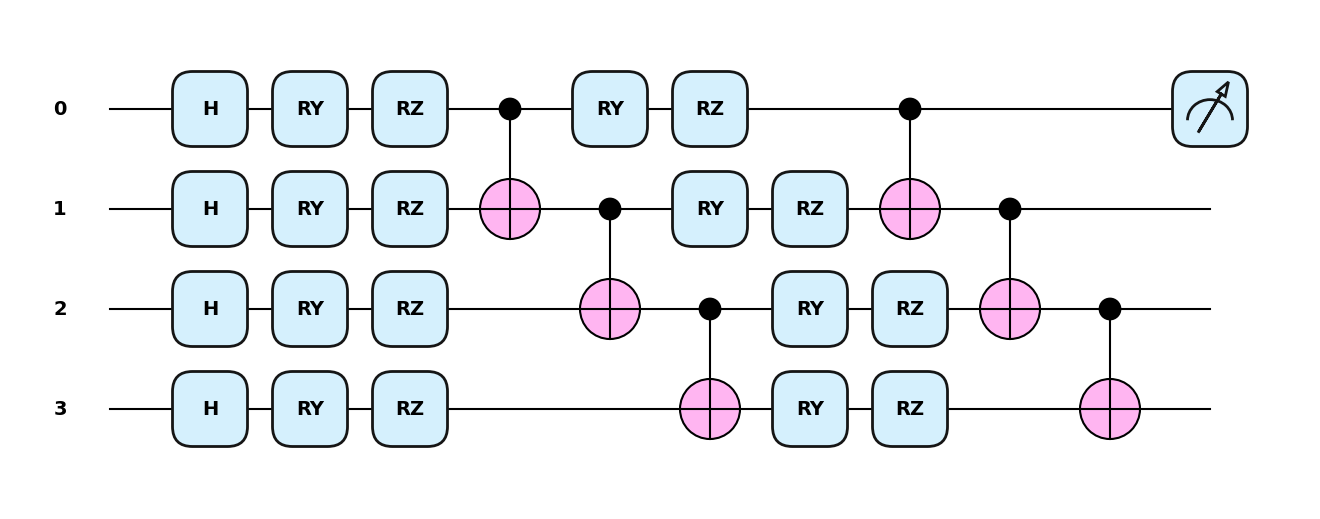

In [1]:
import pennylane as qml
import numpy as np

dev = qml.device('default.qubit', wires=4)

@qml.qnode(dev)
def circuito_hea_draw(params):
    for i in range(4):
        qml.Hadamard(wires=i)
    for camada in range(2):
        offset = camada * 4 * 2
        for i in range(4):
            qml.RY(params[offset + i], wires=i)
            qml.RZ(params[offset + 4 + i], wires=i)
        for i in range(3):
            qml.CNOT(wires=[i, i + 1])
    return qml.expval(qml.PauliZ(0))

params = np.zeros(16)

# Opção 1 — imprime no terminal (texto)
print(qml.draw(circuito_hea_draw)(params))

# Opção 2 — salva como figura (recomendado para o trabalho)
fig, ax = qml.draw_mpl(circuito_hea_draw, decimals=None, style="pennylane")(params)
fig.savefig("circuito_hea.png", dpi=200, bbox_inches="tight")